<a href="https://colab.research.google.com/github/phaniraghava1234/physics_informed_neural_networks/blob/main/Aeroacoustics_Scattering_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.special as sp
import time

# ==========================================
# 0. Device Configuration
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [8]:
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("Current device:", torch.cuda.current_device())

CUDA available: True
GPU name: NVIDIA GeForce RTX 2060
Current device: 0


In [9]:
# ==========================================
# 1. Exact Analytical Solver (Acoustic Scattering)
# ==========================================
def exact_acoustic_scattering(x, y, k=4.0, a=0.5):
    """
    Exact analytical solution for acoustic plane wave scattering by a rigid cylinder.
    k: Wavenumber
    a: Radius of the cylinder
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Incident plane wave: p_inc = e^(ikx)
    p_inc = np.exp(1j * k * x)
    p_s = np.zeros_like(p_inc, dtype=np.complex128)
    
    # Infinite series expansion for scattered field
    for m in range(25): # 25 terms is enough for convergence at k=4.0
        eps = 1 if m == 0 else 2
        # Derivatives of Bessel (J) and Hankel (H1) functions
        J_prime = sp.jvp(m, k * a)
        H_prime = sp.h1vp(m, k * a)
        
        # Scattering term
        term = -eps * (1j**m) * (J_prime / H_prime) * sp.hankel1(m, k * r) * np.cos(m * theta)
        p_s += term
        
    p_tot = p_inc + p_s
    
    # Mask out the interior of the cylinder for plotting
    p_tot[r < a] = np.nan 
    
    return np.real(p_tot), np.imag(p_tot)

# ==========================================
# 2. Draw Geometry & System Schematic
# ==========================================
def draw_geometry():
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Draw Domain (Annulus)
    outer_circle = patches.Circle((0, 0), 2.0, fill=True, color='lightblue', alpha=0.3, ec='blue', lw=2)
    ax.add_patch(outer_circle)
    
    # Draw Rigid Cylinder (Strut)
    inner_circle = patches.Circle((0, 0), 0.5, fill=True, color='gray', ec='black', lw=3)
    ax.add_patch(inner_circle)
    
    # Annotations
    ax.text(0, 0, 'Rigid Strut\n(Hard Wall Neumann BC)\n$\\nabla p \cdot \mathbf{n} = 0$', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            
    ax.text(0, 2.15, 'Outer Boundary (Exact Dirichlet Data)', ha='center', fontsize=12, color='blue')
    
    # Incident Wave Arrows
    for y_pos in [-1.5, -0.75, 0, 0.75, 1.5]:
        ax.arrow(-3.0, y_pos, 0.8, 0, head_width=0.1, head_length=0.2, fc='red', ec='red')
    ax.text(-2.6, 1.7, 'Incident Sound Wave\n$p_{inc} = e^{ikx}$', color='red', fontsize=12, fontweight='bold')
    
    ax.set_xlim(-3.2, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Problem 6: Aeroacoustic Scattering (Helmholtz Equation)', fontsize=15, fontweight='bold', y=1.05)
    
    plt.savefig('aeroacoustics_geometry.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Geometry diagram saved as 'aeroacoustics_geometry.png'")

draw_geometry()


<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\c'
C:\Users\phani\AppData\Local\Temp\ipykernel_5244\2964952168.py:50: SyntaxWarning: invalid escape sequence '\c'
  ax.text(0, 0, 'Rigid Strut\n(Hard Wall Neumann BC)\n$\\nabla p \cdot \mathbf{n} = 0$',


Geometry diagram saved as 'aeroacoustics_geometry.png'


In [15]:
# ==========================================
# 3. Neural Network Architecture 
# ==========================================
class HelmholtzPINN(nn.Module):
    def __init__(self, layers):
        super(HelmholtzPINN, self).__init__()
        self.activation = nn.Tanh()
        
        # Fourier Feature Embedding
        self.B = nn.Parameter(torch.randn(2, layers[1]//2) * 1.0, requires_grad=False)
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(1, len(layers)-1)])
        
        for i in range(len(self.linears)):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        w = 2.0 * np.pi * inputs @ self.B
        a = torch.cat([torch.cos(w), torch.sin(w)], dim=-1)
        
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
            
        out = self.linears[-1](a)
        return out[:, 0:1], out[:, 1:2] # p_real, p_imag

# ==========================================
# 4. Physics-Informed Loss Components
# ==========================================
def compute_physics_loss(model, x_f, y_f, k):
    x_f.requires_grad_(True); y_f.requires_grad_(True)
    p_real, p_imag = model(x_f, y_f)
    
    pr_x = torch.autograd.grad(p_real, x_f, grad_outputs=torch.ones_like(p_real), create_graph=True)[0]
    pr_y = torch.autograd.grad(p_real, y_f, grad_outputs=torch.ones_like(p_real), create_graph=True)[0]
    pr_xx = torch.autograd.grad(pr_x, x_f, grad_outputs=torch.ones_like(pr_x), create_graph=True)[0]
    pr_yy = torch.autograd.grad(pr_y, y_f, grad_outputs=torch.ones_like(pr_y), create_graph=True)[0]
    
    pi_x = torch.autograd.grad(p_imag, x_f, grad_outputs=torch.ones_like(p_imag), create_graph=True)[0]
    pi_y = torch.autograd.grad(p_imag, y_f, grad_outputs=torch.ones_like(p_imag), create_graph=True)[0]
    pi_xx = torch.autograd.grad(pi_x, x_f, grad_outputs=torch.ones_like(pi_x), create_graph=True)[0]
    pi_yy = torch.autograd.grad(pi_y, y_f, grad_outputs=torch.ones_like(pi_y), create_graph=True)[0]
    
    f_real = pr_xx + pr_yy + (k**2) * p_real
    f_imag = pi_xx + pi_yy + (k**2) * p_imag
    
    return torch.mean(f_real**2) + torch.mean(f_imag**2)

def compute_neumann_bc(model, x_in, y_in, a):
    x_in.requires_grad_(True); y_in.requires_grad_(True)
    p_real, p_imag = model(x_in, y_in)
    
    pr_x = torch.autograd.grad(p_real, x_in, grad_outputs=torch.ones_like(p_real), create_graph=True)[0]
    pr_y = torch.autograd.grad(p_real, y_in, grad_outputs=torch.ones_like(p_real), create_graph=True)[0]
    pi_x = torch.autograd.grad(p_imag, x_in, grad_outputs=torch.ones_like(p_imag), create_graph=True)[0]
    pi_y = torch.autograd.grad(p_imag, y_in, grad_outputs=torch.ones_like(p_imag), create_graph=True)[0]
    
    normal_grad_real = (x_in * pr_x + y_in * pr_y) / a
    normal_grad_imag = (x_in * pi_x + y_in * pi_y) / a
    return torch.mean(normal_grad_real**2) + torch.mean(normal_grad_imag**2)

# ==========================================
# 5. Training Data Generation (FIXED BOUNDARIES)
# ==========================================
k_wave = 4.0; a_cyl = 0.5; R_out = 2.0
N_f = 20000; N_in = 1200; N_out = 1200

# 1. Collocation Points (Area sampling)
r_f = np.sqrt(np.random.uniform(a_cyl**2, R_out**2, (N_f, 1)))
theta_f = np.random.uniform(0, 2*np.pi, (N_f, 1))
x_f_pt = torch.tensor(r_f * np.cos(theta_f), dtype=torch.float32, device=device)
y_f_pt = torch.tensor(r_f * np.sin(theta_f), dtype=torch.float32, device=device)

# 2. Inner Boundary: FIX - Using perfectly spaced grid instead of random to prevent leakage
theta_in = np.linspace(0, 2*np.pi, N_in).reshape(-1, 1)
x_in_pt = torch.tensor(a_cyl * np.cos(theta_in), dtype=torch.float32, device=device)
y_in_pt = torch.tensor(a_cyl * np.sin(theta_in), dtype=torch.float32, device=device)

# 3. Outer Boundary: FIX - Perfectly spaced grid
theta_out = np.linspace(0, 2*np.pi, N_out).reshape(-1, 1)
x_out = R_out * np.cos(theta_out)
y_out = R_out * np.sin(theta_out)
pr_out_exact, pi_out_exact = exact_acoustic_scattering(x_out, y_out, k=k_wave, a=a_cyl)

x_out_pt = torch.tensor(x_out, dtype=torch.float32, device=device)
y_out_pt = torch.tensor(y_out, dtype=torch.float32, device=device)
pr_out_pt = torch.tensor(pr_out_exact, dtype=torch.float32, device=device)
pi_out_pt = torch.tensor(pi_out_exact, dtype=torch.float32, device=device)


In [16]:
# ==========================================
# 6. Two-Phase Training Loop 
# ==========================================
# Reverted to 128 neurons for faster 15-minute runtime
layers = [2, 128, 128, 128, 128, 2]
model = HelmholtzPINN(layers).to(device)

start_time = time.time()
print("--- Starting Phase 1: Adam Optimizer ---")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs_adam = 8000

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    loss_pde = compute_physics_loss(model, x_f_pt, y_f_pt, k_wave)
    loss_neumann = compute_neumann_bc(model, x_in_pt, y_in_pt, a_cyl)
    
    pr_out_pred, pi_out_pred = model(x_out_pt, y_out_pt)
    loss_dirichlet = torch.mean((pr_out_pred - pr_out_pt)**2) + torch.mean((pi_out_pred - pi_out_pt)**2)
    
    loss = loss_pde + 50.0 * loss_neumann + 50.0 * loss_dirichlet
    loss.backward()
    optimizer_adam.step()
    
    if epoch in [4000, 6000]:
        for g in optimizer_adam.param_groups: g['lr'] *= 0.5
    if epoch % 1000 == 0:
        print(f'Adam Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, PDE: {loss_pde.item():.6f}')

print("\n--- Starting Phase 2: L-BFGS Optimizer ---")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=4000, max_eval=4000,
                                    history_size=50, tolerance_grad=1e-5, tolerance_change=1.0 * np.finfo(float).eps,
                                    line_search_fn="strong_wolfe")
lbfgs_iter = 0
def closure():
    global lbfgs_iter
    optimizer_lbfgs.zero_grad()
    loss_pde = compute_physics_loss(model, x_f_pt, y_f_pt, k_wave)
    loss_neumann = compute_neumann_bc(model, x_in_pt, y_in_pt, a_cyl)
    pr_out_pred, pi_out_pred = model(x_out_pt, y_out_pt)
    loss_dirichlet = torch.mean((pr_out_pred - pr_out_pt)**2) + torch.mean((pi_out_pred - pi_out_pt)**2)
    loss = loss_pde + 50.0 * loss_neumann + 50.0 * loss_dirichlet
    loss.backward()
    lbfgs_iter += 1
    if lbfgs_iter % 500 == 0:
        print(f'L-BFGS Iter: {lbfgs_iter:05d}, Total Loss: {loss.item():.6f}, PDE: {loss_pde.item():.6f}')
    return loss

optimizer_lbfgs.step(closure)
print(f"\nTraining Complete in {(time.time() - start_time):.2f} seconds!")

--- Starting Phase 1: Adam Optimizer ---
Adam Epoch: 00000, Total Loss: 17032.576172, PDE: 15339.421875
Adam Epoch: 01000, Total Loss: 23.608902, PDE: 6.668554
Adam Epoch: 02000, Total Loss: 5.265281, PDE: 3.404670
Adam Epoch: 03000, Total Loss: 2.537549, PDE: 1.992252
Adam Epoch: 04000, Total Loss: 0.685703, PDE: 0.574784
Adam Epoch: 05000, Total Loss: 0.429999, PDE: 0.371544
Adam Epoch: 06000, Total Loss: 0.301111, PDE: 0.263229
Adam Epoch: 07000, Total Loss: 0.214452, PDE: 0.190030

--- Starting Phase 2: L-BFGS Optimizer ---
L-BFGS Iter: 00500, Total Loss: 0.033997, PDE: 0.032161
L-BFGS Iter: 01000, Total Loss: 0.012086, PDE: 0.011527
L-BFGS Iter: 01500, Total Loss: 0.005971, PDE: 0.005664
L-BFGS Iter: 02000, Total Loss: 0.003466, PDE: 0.003283
L-BFGS Iter: 02500, Total Loss: 0.002256, PDE: 0.002138
L-BFGS Iter: 03000, Total Loss: 0.001583, PDE: 0.001496
L-BFGS Iter: 03500, Total Loss: 0.001182, PDE: 0.001115
L-BFGS Iter: 04000, Total Loss: 0.000914, PDE: 0.000859

Training Complete

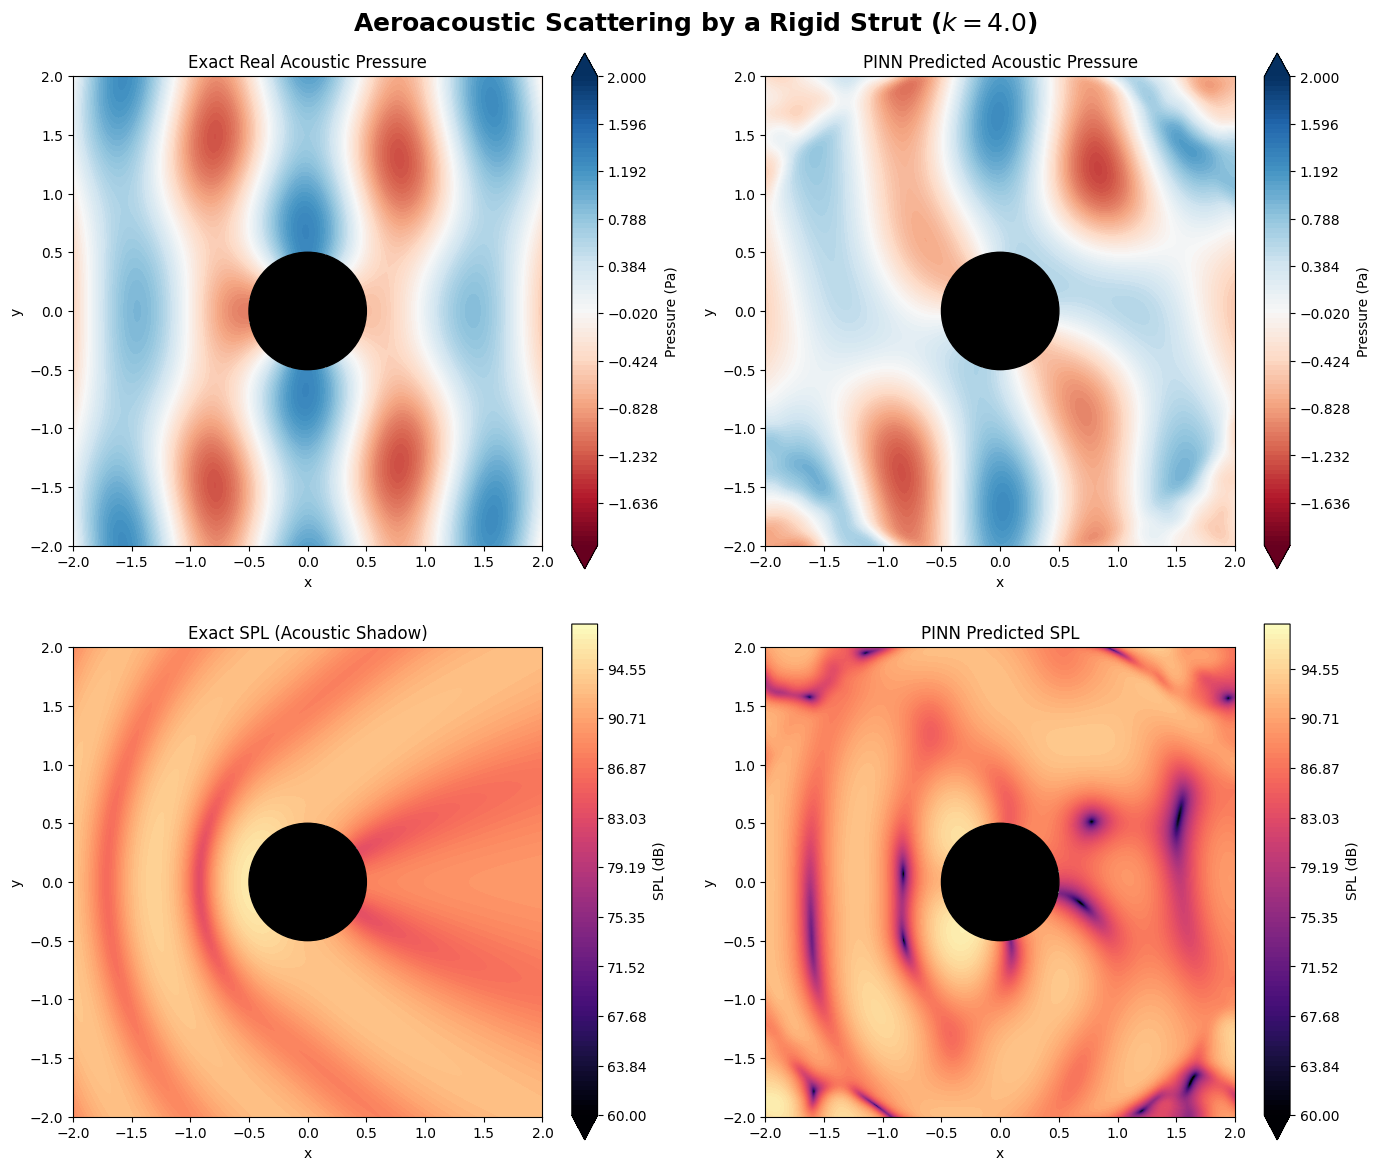

In [19]:
# ==========================================
# 7. Evaluation & Contours
# ==========================================
grid_points = 300 
x_grid = np.linspace(-R_out, R_out, grid_points)
y_grid = np.linspace(-R_out, R_out, grid_points)
X, Y = np.meshgrid(x_grid, y_grid)

X_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device)
Y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    pr_pred, pi_pred = model(X_flat, Y_flat)
    pr_pred = pr_pred.cpu().numpy().reshape(grid_points, grid_points)
    pi_pred = pi_pred.cpu().numpy().reshape(grid_points, grid_points)

pr_exact, pi_exact = exact_acoustic_scattering(X, Y, k=k_wave, a=a_cyl)

# Mask inside cylinder
r_mesh = np.sqrt(X**2 + Y**2)
pr_pred[r_mesh < a_cyl] = np.nan; pi_pred[r_mesh < a_cyl] = np.nan

amp_exact = np.sqrt(pr_exact**2 + pi_exact**2)
amp_pred = np.sqrt(pr_pred**2 + pi_pred**2)

p_ref = 2e-5
spl_exact = 20 * np.log10(amp_exact / (np.sqrt(2) * p_ref) + 1e-5)
spl_pred = 20 * np.log10(amp_pred / (np.sqrt(2) * p_ref) + 1e-5)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Aeroacoustic Scattering by a Rigid Strut ($k=4.0$)', fontsize=18, fontweight='bold')

pr_levels = np.linspace(-2.0, 2.0, 100)
spl_levels = np.linspace(60.0, 98.0, 100)

c1 = axs[0, 0].contourf(X, Y, pr_exact, levels=pr_levels, cmap='RdBu', extend='both')
axs[0, 0].set_title('Exact Real Acoustic Pressure'); axs[0, 0].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c1, ax=axs[0, 0], label='Pressure (Pa)')

c2 = axs[0, 1].contourf(X, Y, pr_pred, levels=pr_levels, cmap='RdBu', extend='both')
axs[0, 1].set_title('PINN Predicted Acoustic Pressure'); axs[0, 1].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c2, ax=axs[0, 1], label='Pressure (Pa)')

c3 = axs[1, 0].contourf(X, Y, spl_exact, levels=spl_levels, cmap='magma', extend='min')
axs[1, 0].set_title('Exact SPL (Acoustic Shadow)'); axs[1, 0].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c3, ax=axs[1, 0], label='SPL (dB)')

c4 = axs[1, 1].contourf(X, Y, spl_pred, levels=spl_levels, cmap='magma', extend='min')
axs[1, 1].set_title('PINN Predicted SPL'); axs[1, 1].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c4, ax=axs[1, 1], label='SPL (dB)')

for ax in axs.flatten(): ax.set_aspect('equal'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('aeroacoustics_contours.png', dpi=300, bbox_inches='tight')
plt.show()

Generating 1D Validation Graphs...


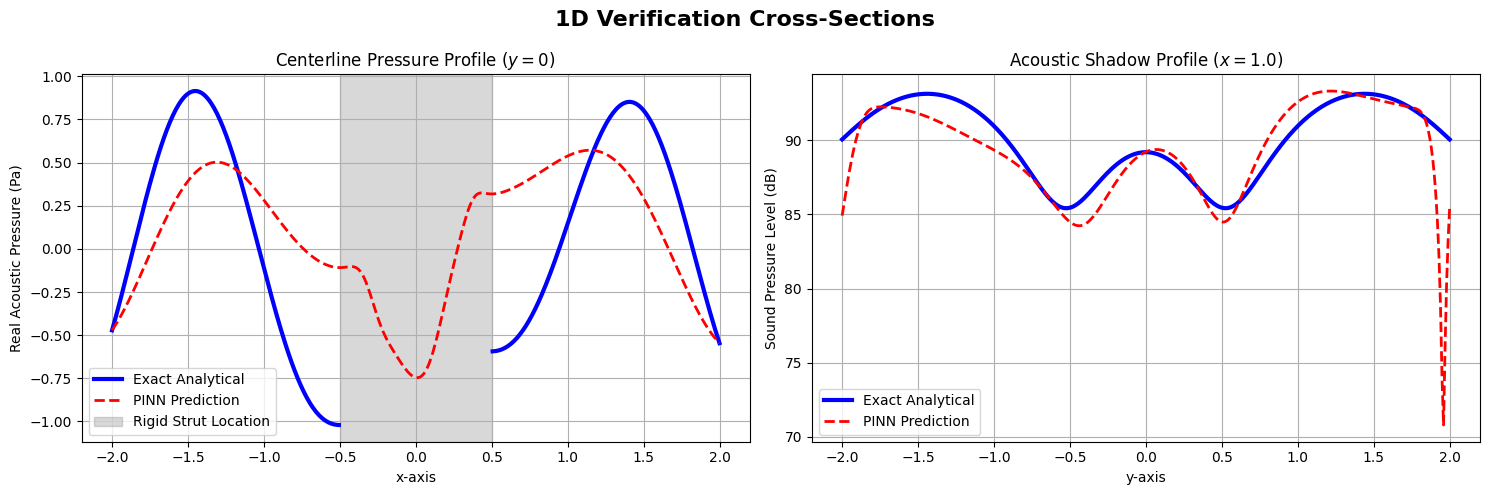

In [18]:
# ==========================================
# 8. NEW: 1D Line Graph Validations
# ==========================================
print("Generating 1D Validation Graphs...")

# Slice 1: Horizontal line directly through the center (y=0)
x_line = np.linspace(-R_out, R_out, 400)
y_line = np.zeros_like(x_line)

x_line_pt = torch.tensor(x_line[:, None], dtype=torch.float32, device=device)
y_line_pt = torch.tensor(y_line[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    pr_pred_line, pi_pred_line = model(x_line_pt, y_line_pt)
    pr_pred_line = pr_pred_line.cpu().numpy().flatten()
    pi_pred_line = pi_pred_line.cpu().numpy().flatten()

pr_exact_line, pi_exact_line = exact_acoustic_scattering(x_line, y_line, k=k_wave, a=a_cyl)

amp_pred_line = np.sqrt(pr_pred_line**2 + pi_pred_line**2)
spl_pred_line = 20 * np.log10(amp_pred_line / (np.sqrt(2) * p_ref) + 1e-5)

amp_exact_line = np.sqrt(pr_exact_line**2 + pi_exact_line**2)
spl_exact_line = 20 * np.log10(amp_exact_line / (np.sqrt(2) * p_ref) + 1e-5)

# Slice 2: Vertical line through the acoustic shadow (x = 1.0)
y_vert = np.linspace(-R_out, R_out, 400)
x_vert = np.full_like(y_vert, 1.0)

x_vert_pt = torch.tensor(x_vert[:, None], dtype=torch.float32, device=device)
y_vert_pt = torch.tensor(y_vert[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    pr_pred_vert, pi_pred_vert = model(x_vert_pt, y_vert_pt)
    pr_pred_vert = pr_pred_vert.cpu().numpy().flatten()
    pi_pred_vert = pi_pred_vert.cpu().numpy().flatten()

pr_exact_vert, pi_exact_vert = exact_acoustic_scattering(x_vert, y_vert, k=k_wave, a=a_cyl)

amp_pred_vert = np.sqrt(pr_pred_vert**2 + pi_pred_vert**2)
spl_pred_vert = 20 * np.log10(amp_pred_vert / (np.sqrt(2) * p_ref) + 1e-5)

amp_exact_vert = np.sqrt(pr_exact_vert**2 + pi_exact_vert**2)
spl_exact_vert = 20 * np.log10(amp_exact_vert / (np.sqrt(2) * p_ref) + 1e-5)

# Plotting the 1D Graphs
fig2, axs2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('1D Verification Cross-Sections', fontsize=16, fontweight='bold')

# Plot 1: Horizontal Centerline Pressure
axs2[0].plot(x_line, pr_exact_line, 'b-', lw=3, label='Exact Analytical')
axs2[0].plot(x_line, pr_pred_line, 'r--', lw=2, label='PINN Prediction')
axs2[0].axvspan(-a_cyl, a_cyl, color='gray', alpha=0.3, label='Rigid Strut Location')
axs2[0].set_title('Centerline Pressure Profile ($y = 0$)')
axs2[0].set_xlabel('x-axis')
axs2[0].set_ylabel('Real Acoustic Pressure (Pa)')
axs2[0].grid(True); axs2[0].legend()

# Plot 2: Vertical SPL Shadow Profile
axs2[1].plot(y_vert, spl_exact_vert, 'b-', lw=3, label='Exact Analytical')
axs2[1].plot(y_vert, spl_pred_vert, 'r--', lw=2, label='PINN Prediction')
axs2[1].set_title('Acoustic Shadow Profile ($x = 1.0$)')
axs2[1].set_xlabel('y-axis')
axs2[1].set_ylabel('Sound Pressure Level (dB)')
axs2[1].grid(True); axs2[1].legend()

plt.tight_layout()
plt.savefig('aeroacoustics_1d_graphs.png', dpi=300, bbox_inches='tight')
plt.show()